# CHAPTER 3 深度神经网络

在第二章中，我们介绍了浅层神经网络的前向传播过程，并引入了**折叠空间**的核心直觉：激活函数 ReLU 赋予神经网络"弯曲"和"折叠"空间的能力，而神经元数量决定了能折叠多少次。

这一章我们将沿着"折叠"这条线索继续深入。第二章的策略是**横向扩展**——在同一层中增加神经元数量。本章我们探讨另一种策略：**纵向扩展**——堆叠多个隐藏层，构建**深度神经网络**。

> 本章的核心参考是 *Understanding Deep Learning*（UDL）第 4 章。

## 3.1 为什么要堆叠层？

回顾第二章，单隐层 ReLU 网络可以理解为：用 $D$ 个隐藏神经元，在输入空间上制造 $D$ 个"折痕"，形成最多 $D+1$ 个线性区域。

但这种方式有一个隐含的低效之处：**每个折痕只能作用于原始输入空间**。如果我们先对输入做一次变换，再在这个**变换后的空间**上施加折痕呢？

这就是深度网络的核心思想：**通过堆叠多个隐藏层，让每一次"折叠"都建立在前一次折叠的结果之上**。

为了建立直觉，我们先考虑一个最简单的深度构造：把**两个**浅层网络首尾相连——第一个网络的输出直接作为第二个网络的输入。

## 3.2 组合两个浅层网络

考虑以下构造（对应 UDL 图 4.1）。两个网络各有 3 个 ReLU 隐藏单元，各自产生 3 段交替斜率的线性区域。

<img src="../attachment/图3-1.jpg" width="700" style="display: block; margin: 0 auto;" >

**第一个网络** $f_1: x \rightarrow y$：

$$
\begin{aligned}
h_1 &= \text{ReLU}[\theta_{10} + \theta_{11} x] \\
h_2 &= \text{ReLU}[\theta_{20} + \theta_{21} x] \\
h_3 &= \text{ReLU}[\theta_{30} + \theta_{31} x] \\
y   &= \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3
\end{aligned}
$$

**第二个网络** $f_2: y \rightarrow y'$：

$$
\begin{aligned}
h'_1 &= \text{ReLU}[\theta'_{10} + \theta'_{11} y] \\
h'_2 &= \text{ReLU}[\theta'_{20} + \theta'_{21} y] \\
h'_3 &= \text{ReLU}[\theta'_{30} + \theta'_{31} y] \\
y'   &= \phi'_0 + \phi'_1 h'_1 + \phi'_2 h'_2 + \phi'_3 h'_3
\end{aligned}
$$

这里注意，y并没有经过激活函数ReLu的处理，是直接作为输入传递到下一个网络当中的，这点很重要。

整体映射为 $y' = f_2(f_1(x))$。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def relu(z):
    return np.maximum(0, z)

class ShallowNet1:
    def __init__(self):
        self.theta_0 = np.array([1.0, 1/3, -1/3])
        self.theta_1 = np.array([1.0, 1.0,  1.0])
        self.phi_0   = -1.0
        self.phi     = np.array([3.0, -6.0, 6.0])

    def forward(self, x):
        h1 = relu(self.theta_0[0] + self.theta_1[0] * x)
        h2 = relu(self.theta_0[1] + self.theta_1[1] * x)
        h3 = relu(self.theta_0[2] + self.theta_1[2] * x)
        y  = self.phi_0 + self.phi[0]*h1 + self.phi[1]*h2 + self.phi[2]*h3
        return y, (h1, h2, h3)

net1 = ShallowNet1()

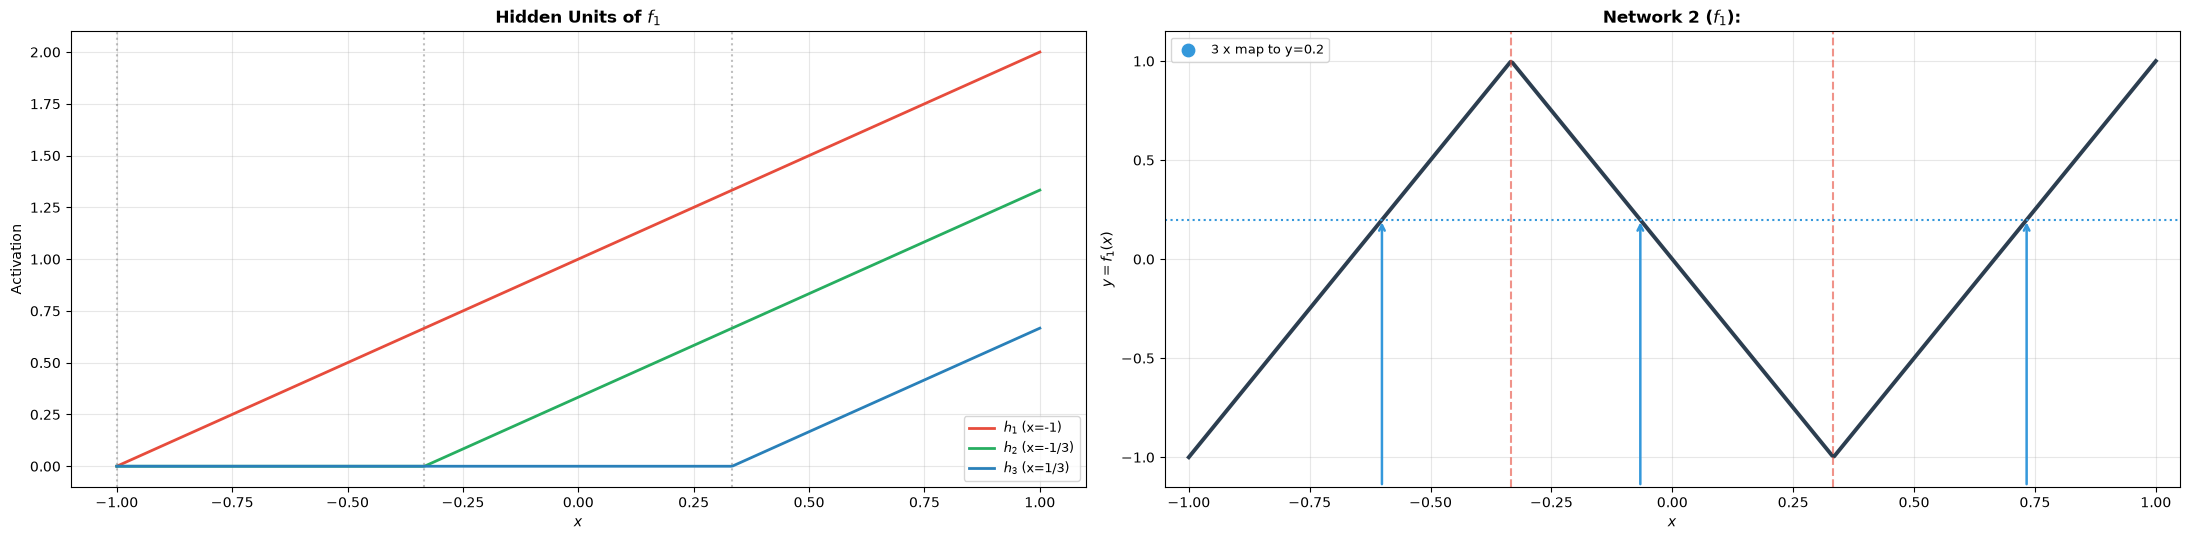

In [8]:
# 可视化第一个网络
x_dense = np.linspace(-1, 1, 500)
y_dense, hs_dense = net1.forward(x_dense)

fig, axes = plt.subplots(1, 2, figsize=(22, 5.5))

# Panel A: 隐藏单元激活
ax = axes[0]
colors_h = ['#E74C3C', '#27AE60', '#2980B9']
for i in range(3):
    ax.plot(x_dense, hs_dense[i], color=colors_h[i], linewidth=2,
            label=[r'$h_1$ (x=-1)', r'$h_2$ (x=-1/3)', r'$h_3$ (x=1/3)'][i])
for jx in [-1, -1/3, 1/3]:
    ax.axvline(x=jx, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('$x$'); ax.set_ylabel('Activation')
ax.set_title('Hidden Units of $f_1$', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(-1.1, 1.1)

# Panel B: f1 输出函数
ax = axes[1]
ax.plot(x_dense, y_dense, '#2C3E50', linewidth=2.8)
for jx in [-1/3, 1/3]:
    ax.axvline(x=jx, color='#E74C3C', linestyle='--', alpha=0.6)

# 展示折叠: 3个不同的x映射到同一个y
y_demo = 0.2
for rx in [np.linspace(-1, -1/3, 500), np.linspace(-1/3, 1/3, 500), np.linspace(1/3, 1, 500)]:
    yr, _ = net1.forward(rx)
    xm = rx[np.argmin(np.abs(yr - y_demo))]
    ax.annotate('', xy=(xm, y_demo), xytext=(xm, -1.15),
                arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.8))
ax.axhline(y=y_demo, color='#3498DB', linestyle=':', linewidth=1.5)
ax.scatter([],[],c='#3498DB',s=80,label=f'3 x map to y={y_demo}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y = f_1(x)$')
ax.set_title('Network 2 ($f_1$):', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15)

plt.tight_layout(); plt.show()

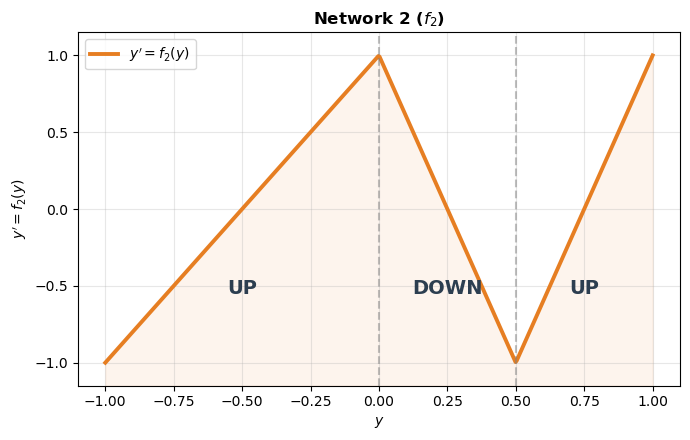

In [2]:
class ShallowNet2:
    def __init__(self):
        self.theta_0 = np.array([1.0, 0.0, -0.5])
        self.theta_1 = np.array([1.0, 1.0,  1.0])
        self.phi_0   = -1.0
        self.phi     = np.array([2.0, -6.0, 8.0])

    def forward(self, y):
        h1 = relu(self.theta_0[0] + self.theta_1[0] * y)
        h2 = relu(self.theta_0[1] + self.theta_1[1] * y)
        h3 = relu(self.theta_0[2] + self.theta_1[2] * y)
        yp = self.phi_0 + self.phi[0]*h1 + self.phi[1]*h2 + self.phi[2]*h3
        return yp, (h1, h2, h3)

net2 = ShallowNet2()
# 可视化 f2
y_dense = np.linspace(-1, 1, 500)
yp_dense, _ = net2.forward(y_dense)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(y_dense, yp_dense, '#E67E22', linewidth=2.8, label=r"$y' = f_2(y)$")
for yj in [0, 0.5]:
    ax.axvline(x=yj, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(y_dense, yp_dense, -1.15, alpha=0.08, color='#E67E22')
for ym, d in [(-0.5, 'UP'), (0.25, 'DOWN'), (0.75, 'UP')]:
    ax.text(ym, -0.55, d, fontsize=14, ha='center', color='#2C3E50', fontweight='bold')
ax.set_xlabel('$y$'); ax.set_ylabel("$y' = f_2(y)$")
ax.set_title('Network 2 ($f_2$)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15)
plt.tight_layout(); plt.show()

下面我们将两个网络组合，看看会出现什么样的结果？

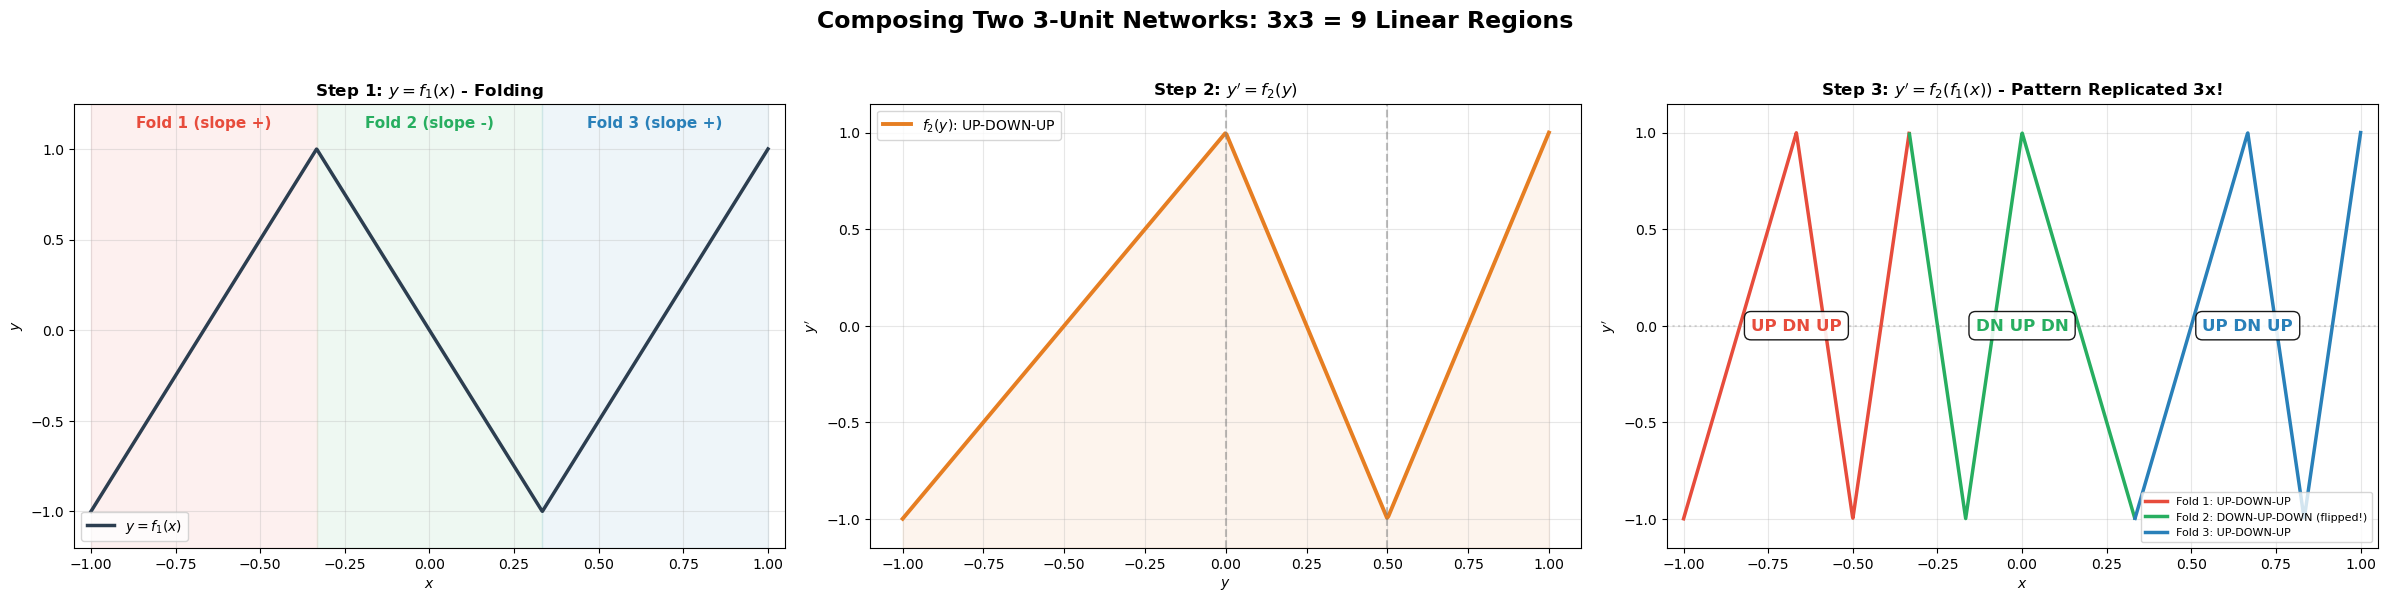

In [3]:
x_dense = np.linspace(-1, 1, 2000)
y_inter, _ = net1.forward(x_dense)
y_final, _ = net2.forward(y_inter)

fig, axes = plt.subplots(1, 3, figsize=(24, 5.8))

fold_colors = ['#E74C3C', '#27AE60', '#2980B9']
fold_bounds = [(-1, -1/3), (-1/3, 1/3), (1/3, 1)]

# Panel A: f1 output
ax = axes[0]
ax.plot(x_dense, y_inter, '#2C3E50', linewidth=2.5, label=r'$y = f_1(x)$')
for (xs,xe),c,lbl in zip(fold_bounds,fold_colors,
    ['Fold 1 (slope +)', 'Fold 2 (slope -)', 'Fold 3 (slope +)']):
    ax.axvspan(xs, xe, alpha=0.08, color=c)
    ax.text((xs+xe)/2, 1.12, lbl, fontsize=11, ha='center', fontweight='bold', color=c)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Step 1: $y = f_1(x)$ - Folding', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.2, 1.25)

# Panel B: f2 on y
ax = axes[1]
yd = np.linspace(-1, 1, 500); ypd, _ = net2.forward(yd)
ax.plot(yd, ypd, '#E67E22', linewidth=2.8, label=r"$f_2(y)$: UP-DOWN-UP")
ax.fill_between(yd, ypd, -1.15, alpha=0.08, color='#E67E22')
for yj in [0, 0.5]:
    ax.axvline(x=yj, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('$y$'); ax.set_ylabel("$y'$")
ax.set_title('Step 2: $y\' = f_2(y)$', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15)

# Panel C: composition
ax = axes[2]
patterns = ['Fold 1: UP-DOWN-UP', 'Fold 2: DOWN-UP-DOWN (flipped!)', 'Fold 3: UP-DOWN-UP']
arrows = ['UP DN UP', 'DN UP DN', 'UP DN UP']
for (xs,xe),c,lbl,arr in zip(fold_bounds,fold_colors,patterns,arrows):
    mask = (x_dense >= xs) & (x_dense <= xe)
    ax.plot(x_dense[mask], y_final[mask], color=c, linewidth=2.5, label=lbl)
    ax.annotate(arr, xy=((xs+xe)/2, 0), fontsize=12, ha='center', va='center',
                color=c, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$'); ax.set_ylabel("$y'$")
ax.set_title('Step 3: $y\'=f_2(f_1(x))$ - Pattern Replicated 3x!', fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15)

fig.suptitle('Composing Two 3-Unit Networks: 3x3 = 9 Linear Regions',
             fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


我们用6个隐藏的神经元，最终创造出了9个线性区域。在我们上一章的理论中，一个单隐藏层网络含有 $D$ 个隐藏神经元，那么它最多能创建 $D + 1$ 个线性区域。显然，通过叠加神经网络的隐藏层，我们可以用更少的参数，去构造更复杂的网络。下面我们就来进一步解释为什么会出现这样的结果。

## 3.3 如何理解组合浅层网络——复合函数的视角

在UDL书中，作者给出两个理解角度，但是我们本质上可以从复合函数的角度出发来理解，我认为从这个角度出发更能体现出“组合网络”中“模式复制”的特殊功能。

我们抛开原来前向传播的思维，先将两个神经网络分别计算出来，变成两个独立的函数。如下图b、c所示。

<img src="../attachment/图3-2.jpg" width="700" style="display: block; margin: 0 auto;" >

我们看到第一个网络被分割成了三段线性区域，第一段线性区域从-1到0的范围被映射到-1到1（即第二个网络的输入空间）当中。实际上就是将网络一的每一段线性区域和网络二做复合运算，输出成新的网络。我们也就自然看到在输出网络中，网络二的模式在网络一划分好的线性区域中，经过不同区域斜率的翻转处理后，重复地出现了三次。（如下图所示）

<img src="../attachment/图3-3.jpg" width="700" style="display: block; margin: 0 auto;" >

但是请你注意，不论是书中给的例子，还是我的代码中的例子都是经过参数设计的，目的就是让你理解这种“模式重复”的巧妙之处，实际上网络曲线不可能每次都出现这种正负交替形式，而且第一个网络的输出还恰好是第二个网络的输入的情况。

这样我们也就直观的感受到了组合浅层神经网络的优势所在。你是否还记得我们刚刚提到的设计组合网络的小心思？第一个的网络输出不经过激活函数处理就直接作为下一个网络的输入传递下去。其实这是从组合浅层网络到搭建深度神经网路的一种过渡手段。下面我们就正式进入深度神经网络了

## 3.4 构建深度神经网络

<img src="../attachment/图3-4.jpg" width="700" style="display: block; margin: 0 auto;" >

我们构建如上含有两个隐藏层的深度神经网络。我们可以将其简单地分成几个步骤：

1. 最先开始从输入层到第一层隐藏单元，首先构造出了三种不同斜率、偏置的线性单元。经过ReLU处理后成为 $h_1$、$h_2$、$h_3$ 输出单元。

$$
\begin{aligned}
h_1 &= a[\theta_{10} + \theta_{11} x] \\
h_2 &= a[\theta_{20} + \theta_{21} x] \\
h_3 &= a[\theta_{30} + \theta_{31} x]
\end{aligned}
$$

2. 再从 $h_1$、$h_2$、$h_3$ 开始到下一层的隐藏层的激活前阶段，输出单元分别经过三次线性组合，构建出三种不同的线性网络，分别作为 $h'_1$、$h'_2$、$h'_3$ 的输入，传递到下一层当中：

$$
\begin{aligned}
h'_1 &= a[\psi_{10} + \psi_{11} h_1 + \psi_{12} h_2 + \psi_{13} h_3] \\
h'_2 &= a[\psi_{20} + \psi_{21} h_1 + \psi_{22} h_2 + \psi_{23} h_3] \\
h'_3 &= a[\psi_{30} + \psi_{31} h_1 + \psi_{32} h_2 + \psi_{33} h_3]
\end{aligned}
$$

<img src="../attachment/图3-5.jpg" width="700" style="display: block; margin: 0 auto;" >

3. 线性网络经过第二层的激活函数处理，增加了新的折叠点位。

<img src="../attachment/图3-6.jpg" width="700" style="display: block; margin: 0 auto;" >

4. 三张线性网络再次经过线性组合，输出最后的网络。

$$
y' = \phi'_0 + \phi'_1 h'_1 + \phi'_2 h'_2 + \phi'_3 h'_3
$$

<img src="../attachment/图3-7.jpg" width="700" style="display: block; margin: 0 auto;" >

经过上面示意的流程以后，我们对深度网络的构建有了更加直观的理解。深层网络在向前传播的过程中，无非就干了三件事: 变换、裁剪（折叠）、最后组合。

> 输入和权重矩阵的内积是在做线性变换，生成不同的模式，再将不同的模式利用ReLU折叠空间，最后利用向量乘法做线性组合，不同的模式被组合在一起形成新的模式，然后循环往复，生成更加复杂的模式。

这种模式构建的方式与单隐藏层网络不同，这种深度网络的模式生成数量是呈指数级增长的。

## 3.5 深度网络的矩阵形式

基于 UDL 第 4.4 节，我们可以用矩阵记号将上述两层网络写成更紧凑的形式。

第一层：

$$
\begin{bmatrix} h_1 \\ h_2 \\ h_3 \end{bmatrix} = a\!\left[\begin{bmatrix} \theta_{10} \\ \theta_{20} \\ \theta_{30} \end{bmatrix} + \begin{bmatrix} \theta_{11} \\ \theta_{21} \\ \theta_{31} \end{bmatrix} x\right]
$$

第二层：

$$
\begin{bmatrix} h'_1 \\ h'_2 \\ h'_3 \end{bmatrix} = a\!\left[\begin{bmatrix} \psi_{10} \\ \psi_{20} \\ \psi_{30} \end{bmatrix} + \begin{bmatrix} \psi_{11} & \psi_{12} & \psi_{13} \\ \psi_{21} & \psi_{22} & \psi_{23} \\ \psi_{31} & \psi_{32} & \psi_{33} \end{bmatrix} \begin{bmatrix} h_1 \\ h_2 \\ h_3 \end{bmatrix}\right]
$$

输出层：

$$
y' = \phi'_0 + \begin{bmatrix} \phi'_1 & \phi'_2 & \phi'_3 \end{bmatrix} \begin{bmatrix} h'_1 \\ h'_2 \\ h'_3 \end{bmatrix}
$$

---

上面的例子是 $D_i=1, D_o=1, D_1=D_2=3$ 的特例。引入统一记号后（遵循 UDL 第 4.4.1 节），可以写出适用于**任意输入输出维度**的通用形式：

- $\mathbf{h}_k$：第 $k$ 层隐藏单元向量（维度 $D_k \times 1$）
- $\boldsymbol{\beta}_{k-1}$：馈入第 $k$ 层的偏置向量（维度 $D_k \times 1$）
- $\boldsymbol{\Omega}_{k-1}$：第 $k-1$ 层到第 $k$ 层的权重矩阵（维度 $D_k \times D_{k-1}$）
- $a[\cdot]$：逐元素应用激活函数

则任意深度的前馈网络可以统一写为（UDL 方程 4.15）：

$$
\boxed{\begin{aligned}
\mathbf{h}_1 &= a\!\left[\boldsymbol{\beta}_0 + \boldsymbol{\Omega}_0 \mathbf{x}\right] \\
\mathbf{h}_2 &= a\!\left[\boldsymbol{\beta}_1 + \boldsymbol{\Omega}_1 \mathbf{h}_1\right] \\
\mathbf{h}_3 &= a\!\left[\boldsymbol{\beta}_2 + \boldsymbol{\Omega}_2 \mathbf{h}_2\right] \\
&\;\;\vdots \\
\mathbf{h}_K &= a\!\left[\boldsymbol{\beta}_{K-1} + \boldsymbol{\Omega}_{K-1} \mathbf{h}_{K-1}\right] \\
\mathbf{y} &= \boldsymbol{\beta}_K + \boldsymbol{\Omega}_K \mathbf{h}_K
\end{aligned}}
$$

或者展开为单一嵌套表达式（UDL 方程 4.16）：

$$
\mathbf{y} = \boldsymbol{\beta}_K + \boldsymbol{\Omega}_K\, a\!\left[\boldsymbol{\beta}_{K-1} + \boldsymbol{\Omega}_{K-1}\, a\!\left[\cdots\, a\!\left[\boldsymbol{\beta}_1 + \boldsymbol{\Omega}_1\, a\!\left[\boldsymbol{\beta}_0 + \boldsymbol{\Omega}_0\mathbf{x}\right]\right]\cdots\right]\right]
$$

其中网络的全体参数 $\phi = \{\boldsymbol{\beta}_k, \boldsymbol{\Omega}_k\}_{k=0}^{K}$ 包含了所有权重矩阵和偏置向量。

> **注意**：这套矩阵记法是**通用的**，不限于单输入单输出。$\mathbf{x}$ 可以是任意 $D_i$ 维向量，$\mathbf{y}$ 可以是任意 $D_o$ 维向量，各隐藏层宽度 $D_k$ 也可以不同。

## 3.6 深度效率（Depth Efficiency）

我们在前面就提到说，为什么要从纵向扩展神经网络，其核心就是在于用更少的参数去构建更复杂的函数。下面这个可视化能给你更好的直觉。

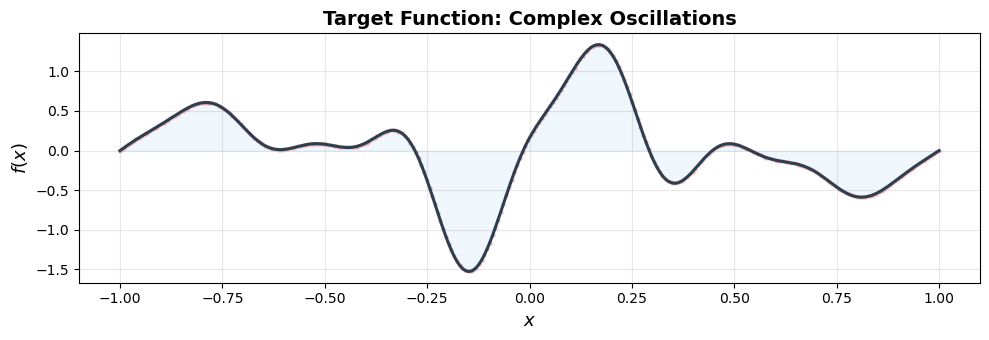

In [7]:
np.random.seed(42)

def complex_target(x):
    return (np.sin(4 * np.pi * x) * np.exp(-x**2 / 0.3) +
            0.3 * np.cos(8 * np.pi * x + 1.0) * (1 - np.abs(x)) +
            0.5 * np.sin(2 * np.pi * x))

X_train = np.linspace(-1, 1, 300).reshape(-1, 1)
y_train = complex_target(X_train).ravel()

fig, ax = plt.subplots(figsize=(10, 3.5))
X_plot = np.linspace(-1, 1, 500)
ax.plot(X_plot, complex_target(X_plot), '#2C3E50', linewidth=2.2)
ax.fill_between(X_plot, complex_target(X_plot), alpha=0.08, color='#3498DB')
ax.scatter(X_train.ravel(), y_train, s=5, alpha=0.3, c='#E74C3C')
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$f(x)$', fontsize=13)
ax.set_title('Target Function: Complex Oscillations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
class DeepNN:
    """K-layer NN with ReLU + Adam"""
    def __init__(self, layer_sizes, lr=0.005, epochs=15000):
        self.layer_sizes = layer_sizes; self.lr = lr; self.epochs = epochs
        self.loss_history = []

    def _init_params(self):
        self.W, self.b = [], []
        for i in range(len(self.layer_sizes)-1):
            di, do = self.layer_sizes[i], self.layer_sizes[i+1]
            self.W.append(np.random.randn(di, do)*np.sqrt(2.0/max(di,1)))
            self.b.append(np.zeros((1, do)))

    def _init_adam(self):
        self.mW=[np.zeros_like(w) for w in self.W]
        self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]
        self.vb=[np.zeros_like(b) for b in self.b]

    def _forward(self, X):
        layers = []; a = X
        for i in range(len(self.W)-1):
            z = a @ self.W[i] + self.b[i]; a = relu(z)
            layers.append((z, a))
        z = a @ self.W[-1] + self.b[-1]
        layers.append((z, z)); return layers

    def fit(self, X, y):
        n = X.shape[0]; y = y.reshape(-1, 1)
        self._init_params(); self._init_adam()
        b1, b2, eps = 0.9, 0.999, 1e-8
        for epoch in range(self.epochs):
            layers = self._forward(X); yp = layers[-1][1]
            loss = np.mean((yp-y)**2); self.loss_history.append(loss)
            L = len(self.W); dL = (2.0/n)*(yp-y)
            for l in reversed(range(L)):
                ap = layers[l-1][1] if l>0 else X
                dW = ap.T @ dL; db = np.sum(dL, axis=0, keepdims=True)
                dL_nxt = None
                if l > 0:
                    dA = dL @ self.W[l].T
                    dL_nxt = dA * (layers[l-1][0] > 0).astype(float)
                t = epoch+1
                for param, grad, m, v in [(self.W[l],dW,self.mW[l],self.vW[l]),
                                           (self.b[l],db,self.mb[l],self.vb[l])]:
                    m[:]=b1*m+(1-b1)*grad; v[:]=b2*v+(1-b2)*grad**2
                    param -= self.lr*(m/(1-b1**t))/(np.sqrt(v/(1-b2**t))+eps)
                if l>0: dL = dL_nxt

    def predict(self, X):
        return self._forward(X)[-1][1].ravel()

def count_params(sizes):
    return sum(sizes[i]*sizes[i+1]+sizes[i+1] for i in range(len(sizes)-1))

configs = [
    ("Shallow Wide (1 layer, 30 units)", [1, 30, 1], '#E74C3C'),
    ("Deep Narrow (4 layers, 5 each)",   [1, 5, 5, 5, 5, 1], '#2980B9'),
]

results = {}
for name, arch, color in configs:
    np.random.seed(42)
    n_p = count_params(arch)
    print(f"Training: {name} - {n_p} params")
    model = DeepNN(layer_sizes=arch, lr=0.008, epochs=20000)
    model.fit(X_train, y_train)
    results[name] = {'model': model, 'params': n_p, 'color': color}
    print(f"  Final MSE: {model.loss_history[-1]:.6f}")

print("\\nTraining complete!")

Training: Shallow Wide (1 layer, 30 units) - 91 params
  Final MSE: 0.074661
Training: Deep Narrow (4 layers, 5 each) - 106 params
  Final MSE: 0.009413
\nTraining complete!


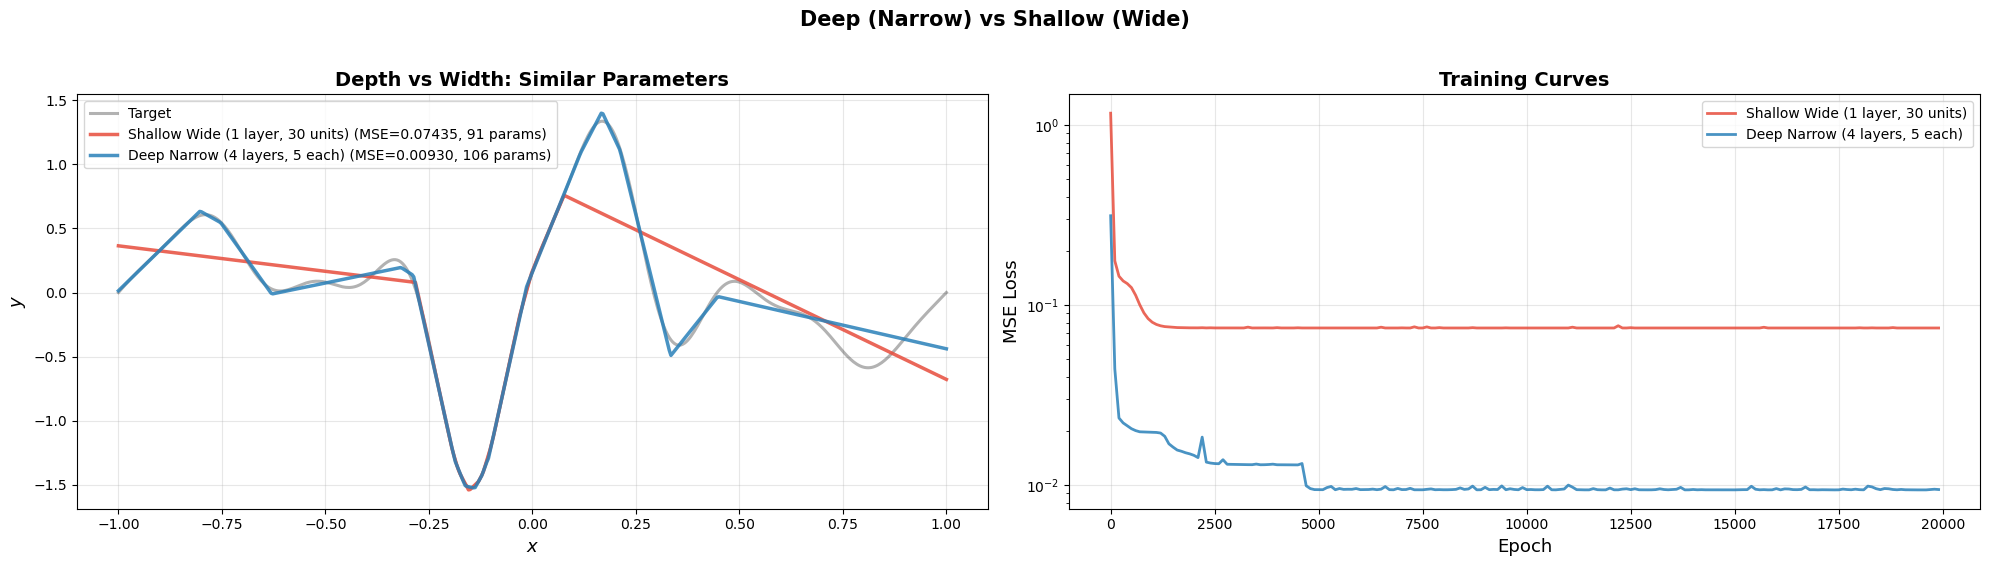

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
X_test = np.linspace(-1, 1, 500).reshape(-1, 1)
y_true = complex_target(X_test).ravel()

ax = axes[0]
ax.plot(X_test, y_true, 'k-', linewidth=2.2, alpha=0.3, label='Target')
for name, res in results.items():
    yp = res['model'].predict(X_test)
    mse = np.mean((yp-y_true)**2)
    ax.plot(X_test, yp, res['color'], linewidth=2.5, alpha=0.85,
            label=f"{name} (MSE={mse:.5f}, {res['params']} params)")
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$y$', fontsize=13)
ax.set_title('Depth vs Width: Similar Parameters', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, res in results.items():
    losses = res['model'].loss_history
    steps = np.arange(0, len(losses), 100)
    ax.plot(steps, [losses[i] for i in steps], res['color'], linewidth=2,
            alpha=0.85, label=name)
ax.set_xlabel('Epoch', fontsize=13); ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

fig.suptitle('Deep (Narrow) vs Shallow (Wide)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 3.7 小结

本章从组合浅层网络逐步过渡到构建深度网络当中。它们二者实际上是截然不同的两种东西，前者在于尽可能保留相同的模式，而后者是产生更多不同的模式。

UDL中给出两种理解组合网络的视角，但实际上只是观察到了它的外在表现，都是片面的。我认为就用最简单的——复合函数的视角，就能把这件事讲的很清楚。也许是它的描述过于晦涩，导致意思没有很好地传达。
